# Implementation of ANN using Keras:

In [40]:
# Importing Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [41]:
# Checking version of Tensorflow ans Keras
print(f"Tensorflow Version {tf.__version__}")
print(f"Keras Version {tf.keras.__version__}")

Tensorflow Version 2.21.0
Keras Version 3.12.2


# GPU / CPU Check

In [42]:
tf.config.list_physical_devices("GPU")

[]

In [43]:
tf.config.list_physical_devices("CPU")

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [44]:
check_list = ['GPU','CPU']

for device in check_list:
  out = tf.config.list_physical_devices(device)
  if len(out) > 0:
    print(f"{device} is available!")
    print(f"Details >> {out}")
  else:
    print(f"{device} isn't available!")

GPU isn't available!
CPU is available!
Details >> [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# Creating a simple classifier using keras on MNIST data

In [45]:
mnist = tf.keras.datasets.mnist
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

In [46]:
print(f"data type of X_train_full: {X_train_full.dtype},\n shape of X_train_full: {X_train_full.shape}")

data type of X_train_full: uint8,
 shape of X_train_full: (60000, 28, 28)


In [47]:
X_test.shape

(10000, 28, 28)

In [48]:
len(X_test[1][0])

28

In [49]:
# create a validation data set from the full training data 
# Scale the data between 0 to 1 by dividing it by 255. as its an unsigned data between 0-255 range
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

# scale the test set as well
X_test = X_test / 255.


In [50]:
len(X_train_full[5000:] )

55000

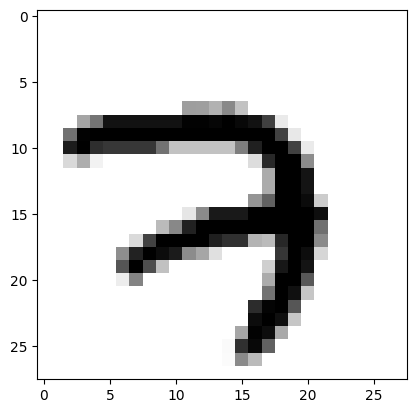

In [51]:
# Lets view some data 
plt.imshow(X_train[0], cmap="binary")
plt.show()

<Axes: >

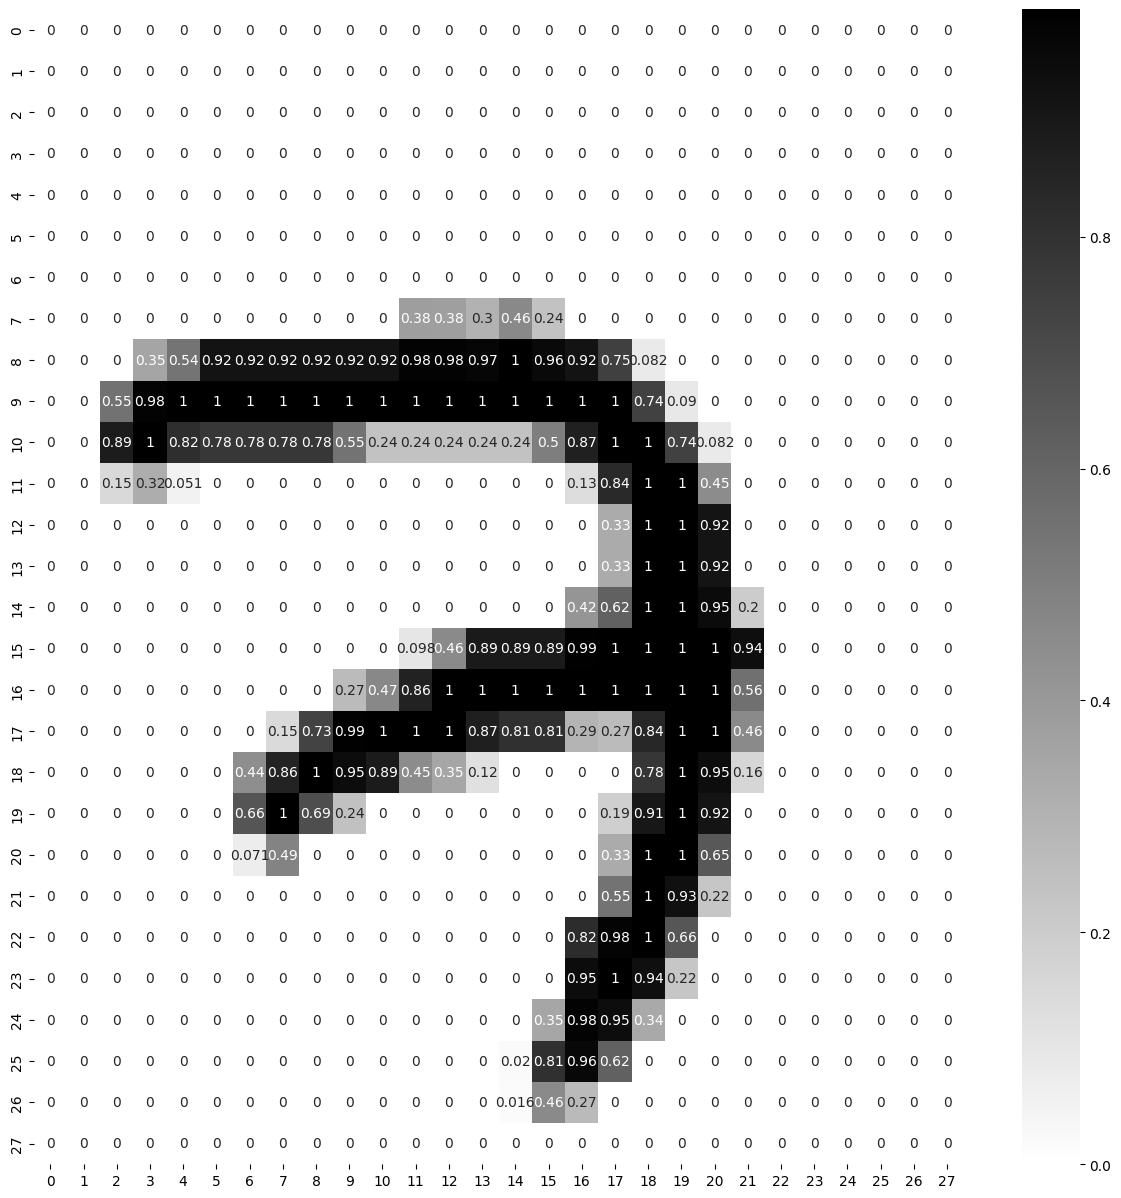

In [52]:
plt.figure(figsize=(15,15))
sns.heatmap(X_train[0], annot=True, cmap="binary")

# Architecture Used:
<img src="https://github.com/entbappy/Branching-tutorial/blob/master/9.png?raw=true"
width="500" 
height="300">

In [53]:
# Creating layers of ANN
LAYERS = [tf.keras.layers.Flatten(input_shape=[28, 28], name="inputLayer"),
          tf.keras.layers.Dense(300, activation="relu", name="hiddenLayer1"),
          tf.keras.layers.Dense(100, activation="relu", name="hiddenLayer2"),
          tf.keras.layers.Dense(10, activation="softmax", name="outputLayer")]

model_clf = tf.keras.models.Sequential(LAYERS)

c:\Users\nayak\anaconda3\envs\ineuron_env\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
model_clf.layers

[<Flatten name=inputLayer, built=True>,
 <Dense name=hiddenLayer1, built=True>,
 <Dense name=hiddenLayer2, built=True>,
 <Dense name=outputLayer, built=True>]

In [55]:
model_clf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputLayer (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hiddenLayer1 (Dense)            │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hiddenLayer2 (Dense)            │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputLayer (Dense)             │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# first Layer * second Layer + bias
784*300 + 300, 300*100+100, 100*10+10

(235500, 30100, 1010)

In [57]:
# Total parameters to be trained 
sum((235500, 30100, 1010))

266610

In [58]:
hidden1 = model_clf.layers[1]
hidden1.name

'hiddenLayer1'

In [59]:
len(hidden1.get_weights()[1])

300

In [60]:
hidden1.get_weights()

[array([[-6.8720564e-02,  4.3934323e-02, -8.1747547e-03, ...,
         -4.7492094e-02, -2.1308396e-02, -2.4400510e-02],
        [ 1.9089907e-02, -1.0867365e-02,  1.8238433e-02, ...,
         -7.0302561e-03, -3.4294702e-02,  3.7404560e-02],
        [ 4.1024983e-03,  6.0930699e-02,  2.3357913e-02, ...,
          1.2858212e-04,  2.0822659e-03, -1.2462795e-02],
        ...,
        [ 2.2284672e-02, -3.0100346e-05,  3.8203664e-02, ...,
         -3.5640404e-02,  4.5605049e-02,  1.2471594e-02],
        [-6.3472107e-02,  9.5727295e-03,  5.5965289e-02, ...,
         -6.5397531e-02, -3.6283508e-02, -6.8437591e-02],
        [ 7.3739097e-02,  4.2039834e-02, -2.2873901e-02, ...,
          3.7998028e-02, -2.0348672e-02, -2.7755149e-02]],
       shape=(784, 300), dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [61]:
weights, biases = hidden1.get_weights()

In [62]:
print("shape\n",weights.shape, "\n")
weights

shape
 (784, 300) 



array([[-6.8720564e-02,  4.3934323e-02, -8.1747547e-03, ...,
        -4.7492094e-02, -2.1308396e-02, -2.4400510e-02],
       [ 1.9089907e-02, -1.0867365e-02,  1.8238433e-02, ...,
        -7.0302561e-03, -3.4294702e-02,  3.7404560e-02],
       [ 4.1024983e-03,  6.0930699e-02,  2.3357913e-02, ...,
         1.2858212e-04,  2.0822659e-03, -1.2462795e-02],
       ...,
       [ 2.2284672e-02, -3.0100346e-05,  3.8203664e-02, ...,
        -3.5640404e-02,  4.5605049e-02,  1.2471594e-02],
       [-6.3472107e-02,  9.5727295e-03,  5.5965289e-02, ...,
        -6.5397531e-02, -3.6283508e-02, -6.8437591e-02],
       [ 7.3739097e-02,  4.2039834e-02, -2.2873901e-02, ...,
         3.7998028e-02, -2.0348672e-02, -2.7755149e-02]],
      shape=(784, 300), dtype=float32)

In [63]:
print("shape\n", biases.shape)

shape
 (300,)


In [64]:
LOSS_FUNCTION = "sparse_categorical_crossentropy" # use => tf.losses.sparse_categorical_crossentropy
OPTIMIZER = "SGD" # or use with custom learning rate=> tf.keras.optimizers.SGD(0.02)
METRICS = ["accuracy"]

model_clf.compile(loss=LOSS_FUNCTION,
              optimizer=OPTIMIZER,
              metrics=METRICS)


In [65]:
# training

EPOCHS = 30
VALIDATION_SET = (X_valid, y_valid)

history = model_clf.fit(X_train, y_train, epochs=EPOCHS,
                    validation_data=VALIDATION_SET, batch_size=32)


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8428 - loss: 0.6157 - val_accuracy: 0.9182 - val_loss: 0.3034
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9185 - loss: 0.2856 - val_accuracy: 0.9346 - val_loss: 0.2369
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9330 - loss: 0.2341 - val_accuracy: 0.9456 - val_loss: 0.2012
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9425 - loss: 0.2009 - val_accuracy: 0.9508 - val_loss: 0.1782
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9495 - loss: 0.1760 - val_accuracy: 0.9552 - val_loss: 0.1604
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9549 - loss: 0.1569 - val_accuracy: 0.9592 - val_loss: 0.1433
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9602 - loss: 0.1410 - val_accuracy: 0.9636 - val_loss: 0.1328
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9641 - loss: 0.1274 - 

In [66]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [67]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.842764,0.615682,0.9182,0.303444
1,0.918491,0.285557,0.9346,0.236865
2,0.933000,0.234053,0.9456,0.201173
3,0.942527,0.200920,0.9508,0.178246
4,0.949473,0.175962,0.9552,0.160440
5,0.954855,0.156949,0.9592,0.143333
6,0.960182,0.140984,0.9636,0.132761
7,0.964055,0.127444,0.9644,0.127443
8,0.966873,0.116529,0.9688,0.114636
9,0.969491,0.106736,0.9710,0.108873


<Axes: >

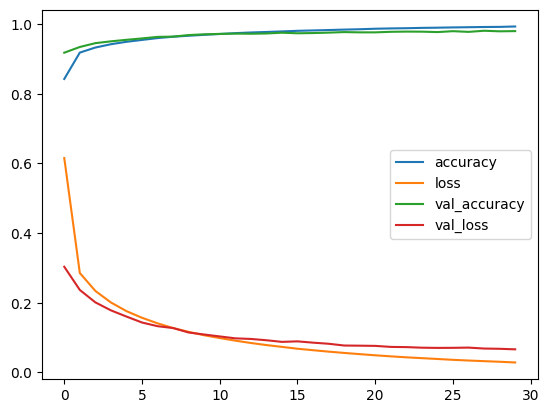

In [68]:
pd.DataFrame(history.history).plot()

In [69]:
model_clf.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - accuracy: 0.9796 - loss: 0.0692


[0.06918413937091827, 0.9796000123023987]

In [70]:
x_new = X_test[:3]
# x_new

In [71]:
actual = y_test[:3]
actual

array([7, 2, 1], dtype=uint8)

In [72]:
y_prob = model_clf.predict(x_new)
y_prob.round(3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 1.   , 0.   ,
        0.   ],
       [0.   , 0.   , 1.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
        0.   ],
       [0.   , 0.997, 0.   , 0.   , 0.   , 0.   , 0.   , 0.002, 0.   ,
        0.   ]], dtype=float32)

In [73]:
y_prob

array([[2.39106748e-06, 1.52258309e-07, 6.06927351e-05, 3.14168952e-04,
        2.00045047e-08, 3.36014949e-07, 2.32474109e-11, 9.99582112e-01,
        9.57819452e-07, 3.90663663e-05],
       [8.28644545e-07, 1.03077327e-04, 9.99864340e-01, 2.54457300e-05,
        3.18902890e-13, 1.02007493e-06, 6.54664944e-08, 9.11693724e-12,
        5.17717262e-06, 1.03572664e-10],
       [4.58239765e-06, 9.96925414e-01, 2.14491229e-04, 1.54657555e-05,
        2.68931442e-04, 5.05251337e-05, 3.60271297e-05, 2.09192000e-03,
        3.84407584e-04, 8.20586138e-06]], dtype=float32)

In [74]:
y_pred = np.argmax(y_prob, axis = -1)

In [75]:
y_pred

array([7, 2, 1])

In [76]:
actual

array([7, 2, 1], dtype=uint8)

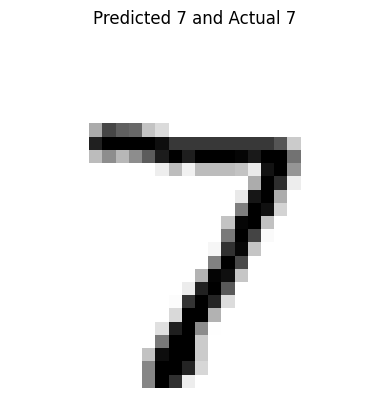

######################


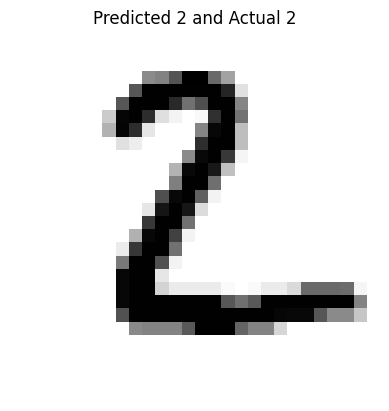

######################


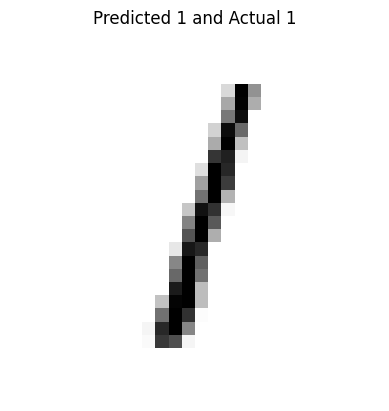

######################


In [77]:
# plot
for data, pred, actual_data in zip(x_new, y_pred, actual):
  plt.imshow(data, cmap="binary")
  plt.title(f"Predicted {pred} and Actual {actual_data}")
  plt.axis("off")
  plt.show() 
  print("######################")